Week 2 — Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('SuperMarket Analysis.csv')
print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])

Rows:  1000
Columns:  17


In [3]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [5]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [8]:
df.median(numeric_only=True)

Unit price                  55.230000
Quantity                     5.000000
Tax 5%                      12.088000
Sales                      253.848000
cogs                       241.760000
gross margin percentage      4.761905
gross income                12.088000
Rating                       7.000000
dtype: float64

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

df['Date'].head()

0   2019-01-05
1   2019-03-08
2   2019-03-03
3   2019-01-27
4   2019-02-08
Name: Date, dtype: datetime64[ns]

In [10]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day_name()

df[['Date', 'Month', 'Day']].head()

,Date,Month,Day
0,2019-01-05,1,Saturday
1,2019-03-08,3,Friday
2,2019-03-03,3,Sunday
3,2019-01-27,1,Sunday
4,2019-02-08,2,Friday


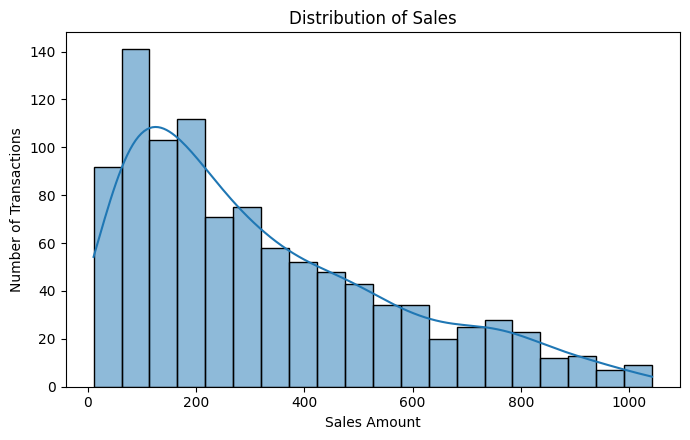

In [11]:
plt.figure(figsize=(7, 4.5))

sns.histplot(
    df['Sales'], kde=True, bins=20
)

plt.title('Distribution of Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

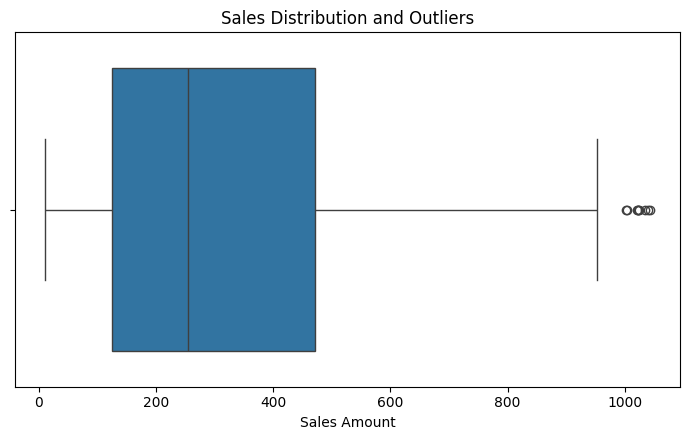

In [12]:
plt.figure(figsize=(7, 4.5))

sns.boxplot(x=df['Sales'])

plt.title('Sales Distribution and Outliers')
plt.xlabel('Sales Amount')

plt.tight_layout()
plt.show()

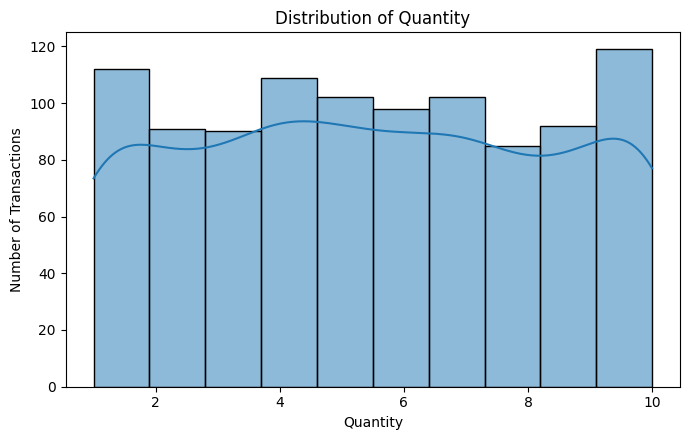

In [13]:
plt.figure(figsize=(7, 4.5))

sns.histplot(
    df['Quantity'],
    bins=10,
    kde=True
)

plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

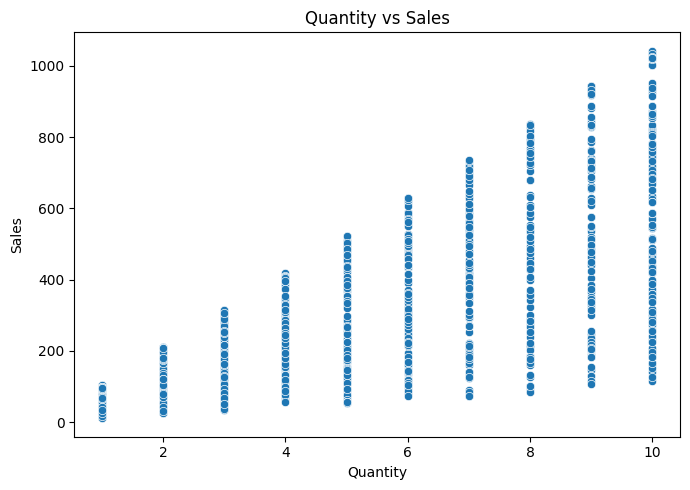

In [14]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='Sales'
)

plt.title('Quantity vs Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

In [15]:
correlation = df['Quantity'].corr(df['Sales'])

print("Correlation between Quantity and Sales:", correlation)

Correlation between Quantity and Sales: 0.7055101859433063


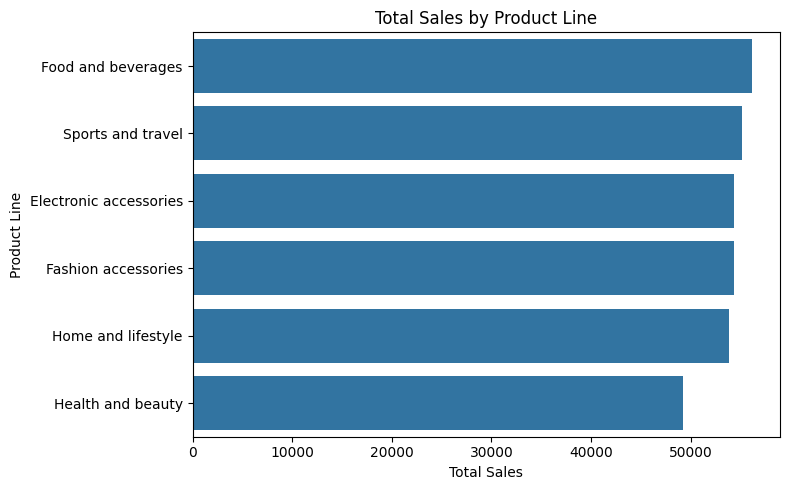

In [16]:
product_sales = (
    df.groupby('Product line')['Sales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=product_sales.values,
    y=product_sales.index
)

plt.title('Total Sales by Product Line')
plt.xlabel('Total Sales')
plt.ylabel('Product Line')

plt.tight_layout()
plt.show()

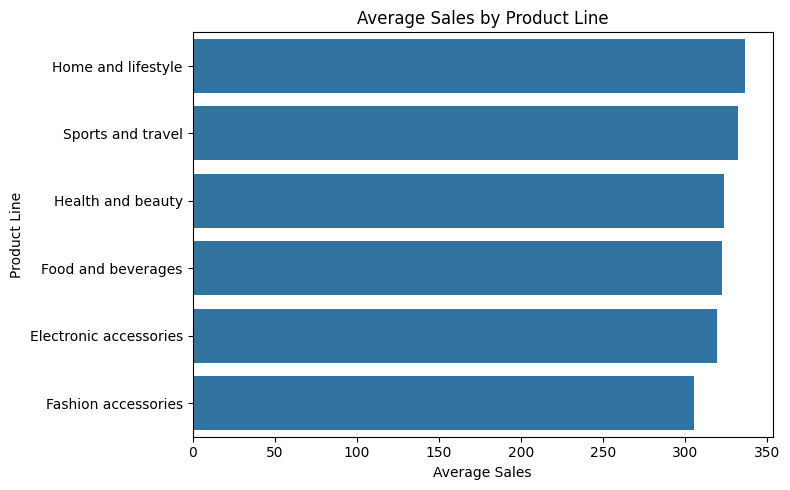

In [17]:
average_sales = (
    df.groupby('Product line')['Sales']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=average_sales.values,
    y=average_sales.index
)

plt.title('Average Sales by Product Line')
plt.xlabel('Average Sales')
plt.ylabel('Product Line')

plt.tight_layout()
plt.show()

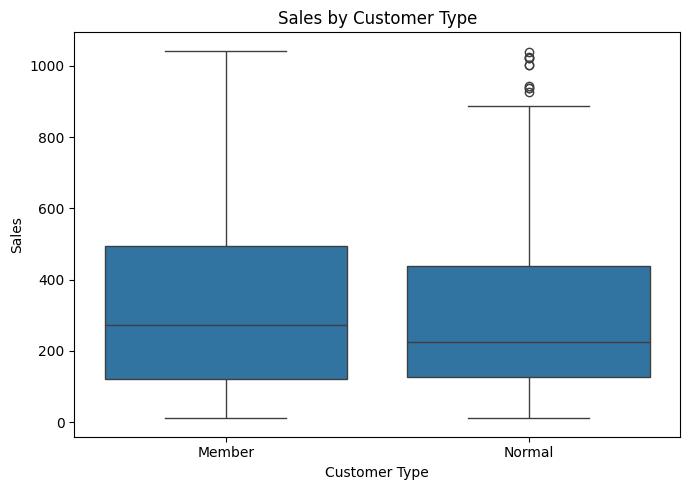

In [18]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='Customer type',
    y='Sales'
)

plt.title('Sales by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

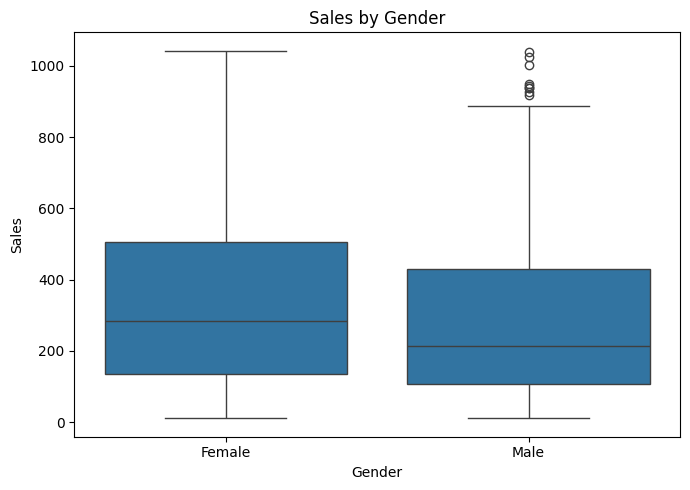

In [19]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='Gender',
    y='Sales'
)

plt.title('Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

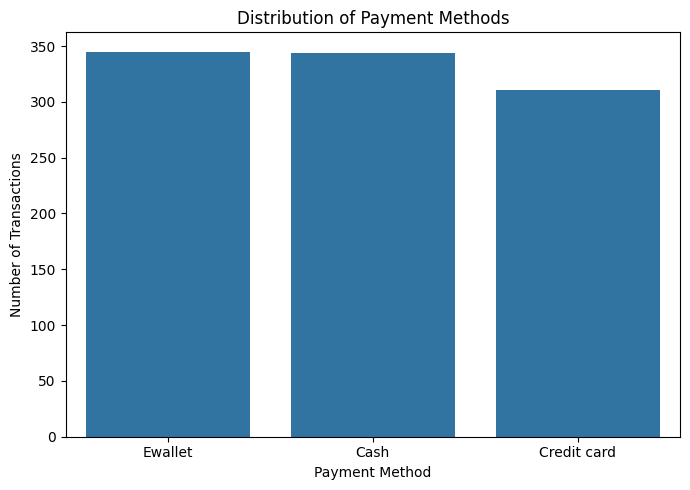

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Payment'
)

plt.title('Distribution of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

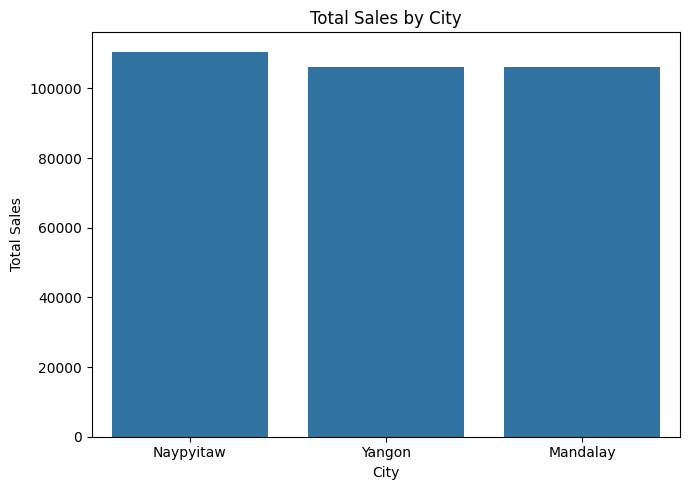

In [21]:
city_sales = (
    df.groupby('City')['Sales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=city_sales.index,
    y=city_sales.values
)

plt.title('Total Sales by City')
plt.xlabel('City')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

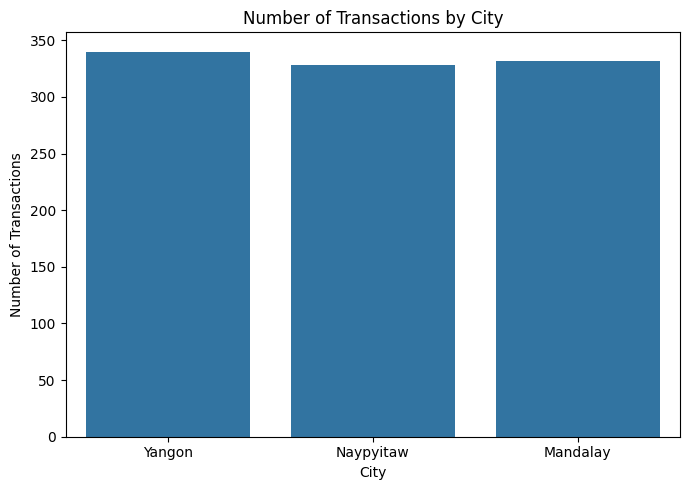

In [22]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='City'
)

plt.title('Number of Transactions by City')
plt.xlabel('City')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

In [23]:
monthly_sales = (
    df.groupby('Month')['Sales']
      .sum()
)

print(monthly_sales)

Month
1    116291.868
2     97219.374
3    109455.507
Name: Sales, dtype: float64


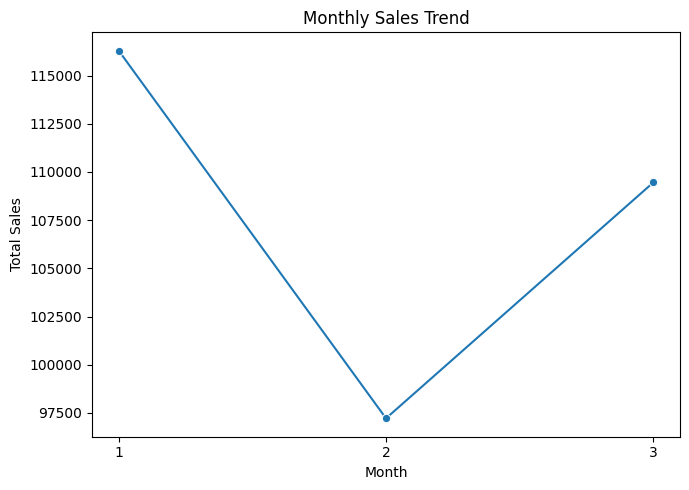

In [25]:
plt.figure(figsize=(7, 5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(monthly_sales.index)

plt.tight_layout()
plt.show()

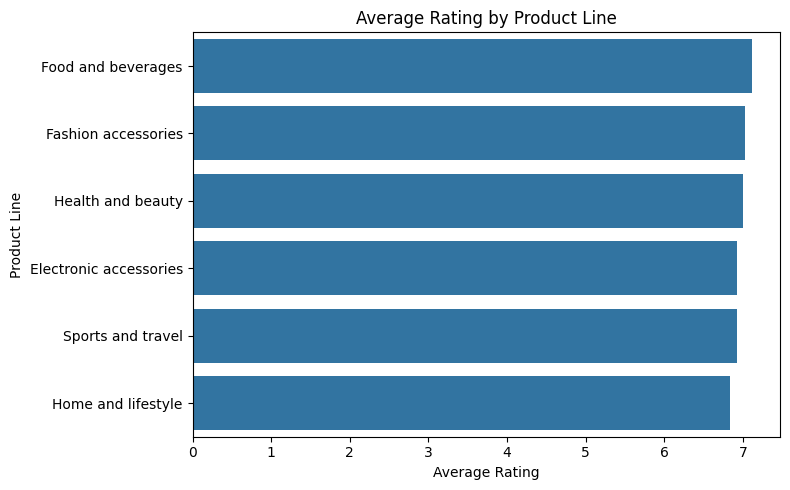

In [26]:
rating_by_product = (
    df.groupby('Product line')['Rating']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=rating_by_product.values,
    y=rating_by_product.index
)

plt.title('Average Rating by Product Line')
plt.xlabel('Average Rating')
plt.ylabel('Product Line')

plt.tight_layout()
plt.show()

In [27]:
numeric_df = df.select_dtypes(include=['number'])

correlation_matrix = numeric_df.corr()

correlation_matrix

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating,Month
Unit price,1.000000,0.010778,0.633962,0.633962,0.633962,NaN,0.633962,-0.008778,-0.027387
Quantity,0.010778,1.000000,0.705510,0.705510,0.705510,NaN,0.705510,-0.015815,-0.014524
Tax 5%,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442,-0.022301
Sales,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442,-0.022301
cogs,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442,-0.022301
gross margin percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gross income,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442,-0.022301
Rating,-0.008778,-0.015815,-0.036442,-0.036442,-0.036442,NaN,-0.036442,1.000000,-0.042880
Month,-0.027387,-0.014524,-0.022301,-0.022301,-0.022301,NaN,-0.022301,-0.042880,1.000000


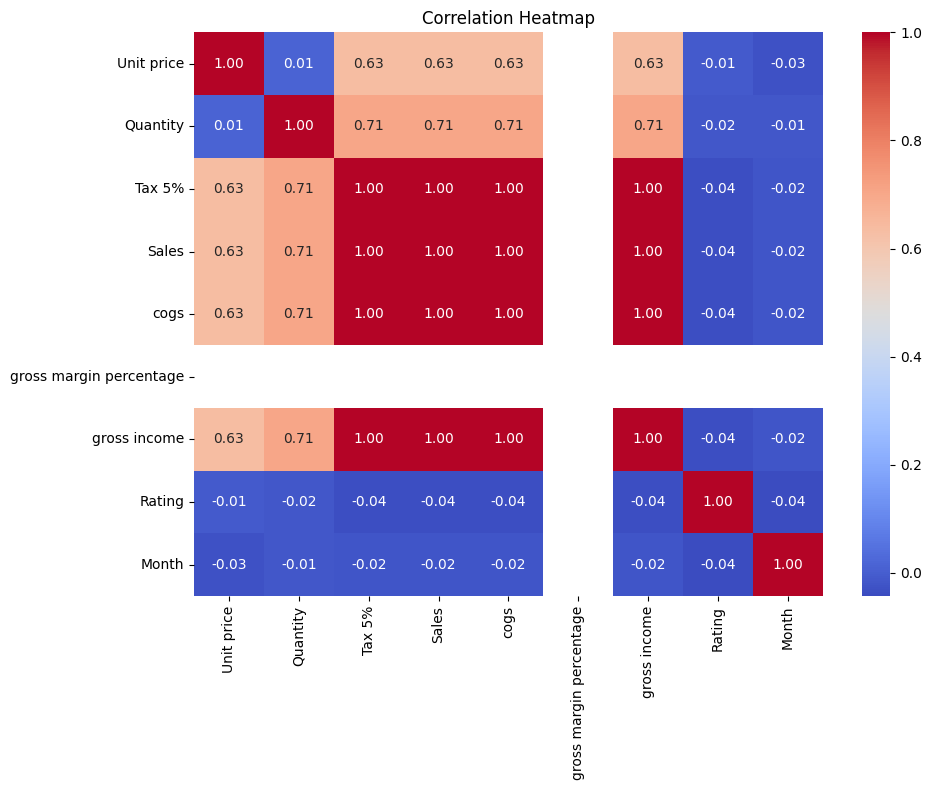

In [29]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [30]:
product_summary = df.groupby('Product line').agg({
    'Sales': ['count', 'mean', 'median', 'sum'],
    'Quantity': 'mean',
    'Rating': 'mean'
})

product_summary

Sales                                     Quantity  \
                       count        mean     median         sum      mean   
Product line                                                                
Electronic accessories   170  319.632538  241.21650  54337.5315  5.711765   
Fashion accessories      178  305.089298  211.64850  54305.8950  5.067416   
Food and beverages       174  322.671517  252.48825  56144.8440  5.471264   
Health and beauty        152  323.643020  272.30700  49193.7390  5.618421   
Home and lifestyle       160  336.636956  258.18975  53861.9130  5.693750   
Sports and travel        166  332.065220  270.93150  55122.8265  5.542169   

                          Rating  
                            mean  
Product line                      
Electronic accessories  6.924706  
Fashion accessories     7.029213  
Food and beverages      7.113218  
Health and beauty       7.003289  
Home and lifestyle      6.837500  
Sports and travel       6.916265

In [31]:
product_summary = df.groupby('Product line').agg({
    'Sales': ['count', 'mean', 'median', 'sum'],
    'Quantity': 'mean',
    'Rating': 'mean'
})

product_summary

Sales                                     Quantity  \
                       count        mean     median         sum      mean   
Product line                                                                
Electronic accessories   170  319.632538  241.21650  54337.5315  5.711765   
Fashion accessories      178  305.089298  211.64850  54305.8950  5.067416   
Food and beverages       174  322.671517  252.48825  56144.8440  5.471264   
Health and beauty        152  323.643020  272.30700  49193.7390  5.618421   
Home and lifestyle       160  336.636956  258.18975  53861.9130  5.693750   
Sports and travel        166  332.065220  270.93150  55122.8265  5.542169   

                          Rating  
                            mean  
Product line                      
Electronic accessories  6.924706  
Fashion accessories     7.029213  
Food and beverages      7.113218  
Health and beauty       7.003289  
Home and lifestyle      6.837500  
Sports and travel       6.916265

In [32]:
print("Average Sales:", round(df['Sales'].mean(), 2))
print("Median Sales:", round(df['Sales'].median(), 2))
print("Average Quantity:", round(df['Quantity'].mean(), 2))
print("Average Rating:", round(df['Rating'].mean(), 2))

print("\nTotal Sales:", round(df['Sales'].sum(), 2))
print("Total Transactions:", len(df))

print("\nQuantity-Sales Correlation:",
      round(df['Quantity'].corr(df['Sales']), 2))

Average Sales: 322.97
Median Sales: 253.85
Average Quantity: 5.51
Average Rating: 6.97

Total Sales: 322966.75
Total Transactions: 1000

Quantity-Sales Correlation: 0.71
